## Bi-Encoder with GloVe

Includes attention score heatmap below.

In [2]:
# Global hyperparams
DATASET_SIZE = 'small' # 'large' #
BATCH_SIZE = 256

# Multi-head self-attention
DROPOUT = 0.2
HEAD_NUM = 4
HEAD_DIM = 64 
INTERMEDIATE_DIM = 200 

# Padding / truncating
MAX_IMPRESSIONS = 25 
MAX_HISTORY_LENGTH = 25 
MAX_TITLE_LENGTH = 20 
VOCAB_SIZE = 20000

# Regularisation
LAMBDA_DIVERSITY = 350
LAMBDA_NOVELTY = 6

## Load the Dataset

In [3]:
from recs import *

data = DataLoader(BATCH_SIZE, data_size=DATASET_SIZE)

vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE, output_sequence_length=MAX_TITLE_LENGTH)

train_dataset = data.get_train_ds(vectorizer) 
val_dataset = data.get_val()

## Build the News Encoder

In [4]:
title_input = keras.Input(
    shape=(MAX_TITLE_LENGTH,), dtype="int32", name='news_encoder_input')

x = GloveEmbedding(DATASET_SIZE)(title_input)

x = layers.Dropout(DROPOUT)(x) # in nmrs
attention_output, attention_scores = layers.MultiHeadAttention(
    num_heads=HEAD_NUM, key_dim=HEAD_DIM, 
    dropout=DROPOUT)(x, x, return_attention_scores=True)

title_vector = AttentionPooling()(attention_output) 
# title_vector = SoftAttention()(attention_output) 

news_encoder = keras.Model(title_input, title_vector, name="news_encoder")

# reuse model weights for inspection
# news_encoder_w_attention = keras.Model(title_input, [title_vector, attention_scores], name="news_encoder_att")

## Build the User Encoder

In [5]:
history_input = keras.Input(
    shape=(MAX_HISTORY_LENGTH, MAX_TITLE_LENGTH), dtype="int32", name='user_history_encoder')

# Embed all titles (MAX_TITLE_LENGTH > EMBED_DIM)
a = layers.TimeDistributed(news_encoder)(history_input)

a, attention_scores = layers.MultiHeadAttention(
    HEAD_NUM, HEAD_DIM, dropout=DROPOUT)(a, a, return_attention_scores=True) # (None, 20, 100)

b = layers.Dense(INTERMEDIATE_DIM, activation='relu')(a)    # (None, 20, 200)
b = layers.Dense(ops.shape(a)[-1])(b)                       # (None, 20, 100)
b = layers.Add()([a, b])

encoded_user = AttentionPooling()(b)
user_encoder = keras.Model(history_input, encoded_user, name="user_encoder")

# reuse model weights for inspection
# user_encoder_w_attention = keras.Model(history_input, [encoded_user, attention_scores], name="user_encoder_att")

## Build the Main Model

In [6]:
history_input = keras.Input(
    shape=(MAX_HISTORY_LENGTH, MAX_TITLE_LENGTH), dtype="int32", name='user_history_input')
candidate_input = keras.Input(
    shape=(None, MAX_TITLE_LENGTH), dtype="int32", name='candidate_input') 

encoded_user = user_encoder(history_input)                                    # (None, 100)  
encoded_candidates = layers.TimeDistributed(news_encoder)(candidate_input)    # (None, 20, 100)  

logits = layers.Dot(-1)([encoded_user, encoded_candidates])

logits = DiversityRegularisation(lambda_diversity=LAMBDA_DIVERSITY)(logits, encoded_candidates) 

preds = layers.Softmax()(logits)
model = keras.Model([history_input, candidate_input], preds)

## Train the model

In [28]:
model.compile(optimizer=keras.optimizers.Adam(5e-4),
              loss=RankLoss(), metrics=[MaskedAUC()]) 

In [ ]:
# Test
loss_fn = RankLoss()

inputs, labels = list(train_dataset.take(1))[0]
with tf.GradientTape() as tape:
    predictions = model(inputs, training=True)        
    rank_loss = loss_fn(labels, predictions)
    regularisation = model.compute_loss(y=labels, y_pred=predictions)
    
    print(f"Total loss: {regularisation.numpy():.2f} \
            \nRank loss: {rank_loss:.2f} (Difference: {rank_loss-regularisation.numpy():.2f})")

In [29]:
history = model.fit(
    train_dataset,     
    validation_data=val_dataset,
    epochs=5,
    verbose=1,
    callbacks=[
    keras.callbacks.EarlyStopping(monitor='val_masked_auc', mode='max')],
    steps_per_epoch=data.steps_per_epoch,
    validation_steps=data.validation_steps,
)

Epoch 1/5
613/613 ━━━━━━━━━━━━━━━━━━━━ 48s 29ms/step - loss: 2110.2061 - masked_auc: 0.6825 - val_loss: 2149.5024 - val_masked_auc: 0.7060
Epoch 2/5
613/613 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 2083.4165 - masked_auc: 0.7252 - val_loss: 2148.8315 - val_masked_auc: 0.7039


### Test and log results

In [ ]:
test_dataset = data.get_test()
y_pred = model.predict(test_dataset)

log_results(y_true=data.test_labels, 
            y_pred=y_pred, 
            dataset_size=DATASET_SIZE,
            imprs=data.test_imprs, 
            modelname='glove_large', 
            history=history
            )

/home/jonux/miniconda3/envs/neural/lib/python3.10/site-packages/tensorflow/python/ops/array_ops.py:3716: RuntimeWarning: divide by zero encountered in remainder
  pad_end_extra = (block_shape - full_input_shape % block_shape) % block_shape


984/984 ━━━━━━━━━━━━━━━━━━━━ 255s 253ms/step
Saved model predictions here: ../.data/glove_300_large.npy


,glove_300_large
modelname,glove_300_large
dataset_size,large
timestamp,2025-03-28 15:40
auc,0.7395
mean_mrr,0.3189
ndcg@5,0.3511
ndcg@10,0.4116
mean_epc,1.2806
mean_intra_list_diversity,0.2434
mean_surprisal,8.0267



---

Backed up in attention_plots.ipynb

In [ ]:
plt.rcParams['text.usetex'] = True

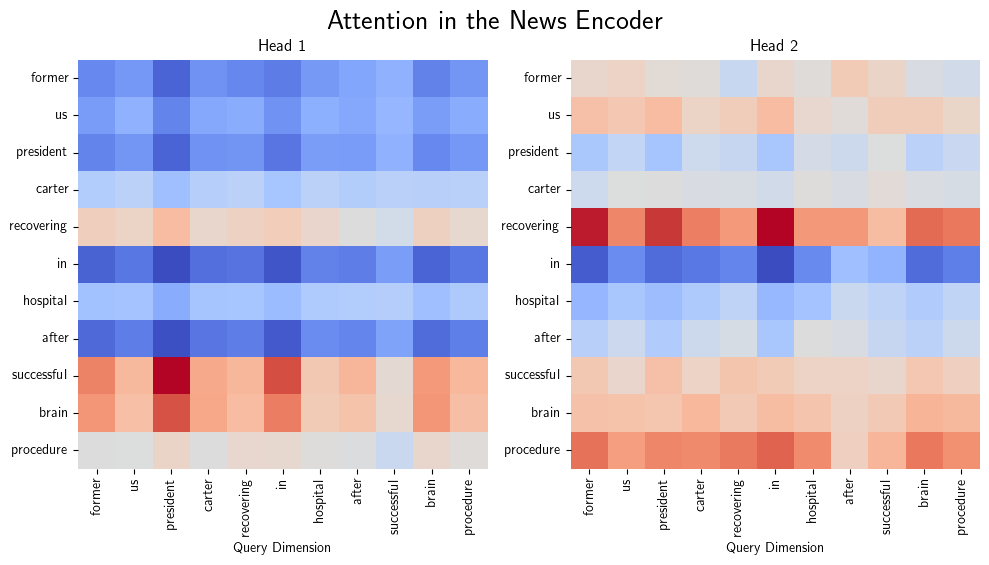

In [ ]:
#| fig-cap: "A heatmap of the activations in the News Encoder"
#| label: fig-news-encoder

def extract_candidate_title():
    """take one title of the first sequence"""
    candidates = list(train_dataset.take(1))[0][0][1]
    one_title = candidates[0, 0] # << the title within the candidate list 
    one_title = ops.expand_dims(one_title, 0) # add batch dim
    _, attention_scores = news_encoder_w_attention(one_title)    
    attention_scores = attention_scores[0]
    mask = one_title != 0
    idx = np.where(mask)[1]
    tokens = np.array(data.vectorizer.get_vocabulary())[one_title.numpy()][mask]

    num_heads = attention_scores.shape[0]
    _, ax = plt.subplots(1, num_heads, figsize=(10, 6))
    
    for i in range(num_heads):
        sns.heatmap(attention_scores.numpy()[i, idx][:, idx].T, cmap='coolwarm', ax=ax[i],
                    xticklabels=tokens, yticklabels=tokens, square=True, cbar=False)
        ax[i].set_title(f'Head {i+1}')
        ax[i].set_xlabel('Query Dimension')
        
    # ax[0].set_ylabel('Key Tokens')    
    plt.tight_layout()
    plt.suptitle('Attention in the News Encoder', y=0.95, fontsize='20')
    plt.show()

extract_candidate_title()

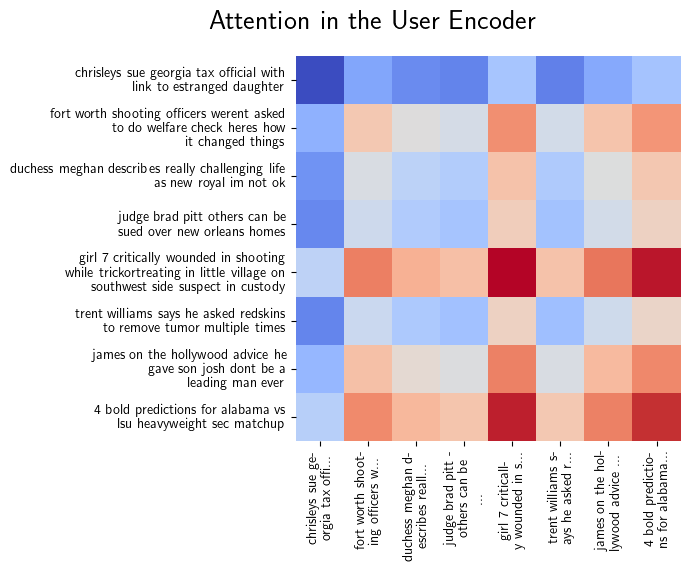

In [ ]:
#| fig-cap: "A heatmap of the activations in the User Encoder"
#| label: fig-user-encoder

# extract one sequence
history_seq = list(train_dataset.take(1))[0][0][0]
history_seq = ops.cast(history_seq, tf.int32)

_, attention_scores = user_encoder_w_attention(history_seq)

if attention_scores.ndim > 3:
    attention_scores = attention_scores[0] # drop batch dim
    history_seq = history_seq[0]

titles = []
for title in history_seq:
    mask = title != 0
    idx = np.where(mask)[0]
    tokens = np.array(data.vectorizer.get_vocabulary())[title.numpy()][mask]
    if tokens.size > 0: 
        tokens = [t for t in tokens if "[UNK]" not in t]
        titles.append('\n'.join(' '.join(tokens[i:i+6]) for i in range(0,len(tokens), 6)))

_, axs = plt.subplots(figsize=(10,5))
sns.heatmap(attention_scores.numpy()[0,-8:,-8:].T,
            cmap='coolwarm', 
            yticklabels=titles[-8:],
            xticklabels=[t[:16]+'-\n'+t[16:30]+'...' for t in titles if i == 1][-8:],            
            cbar=False, square=True, ax=axs)

# plt.xlabel('Key')
# plt.ylabel('Query')
plt.title('Attention in the User Encoder', y=1.05, x=.2, fontsize='20')
plt.show()